In [1]:
import time
import numpy as np
import pandas as pd
import faiss

product_embeddings = np.load("../artifacts/indexes/product_embeddings.npy")
product_ids = pd.read_csv("../artifacts/indexes/product_embedding_ids.csv")["product_id"].to_numpy()

query_embeddings = np.load("../artifacts/indexes/query_embeddings.npy")
query_ids_emb = pd.read_csv("../artifacts/indexes/query_embedding_ids.csv")["query_id"].to_numpy()

judgments = pd.read_parquet("../data/processed/judgments.parquet")
val_ids = set(pd.read_csv("../data/processed/splits/validation_query_ids.csv")["query_id"])

val_mask = np.isin(query_ids_emb, list(val_ids))
val_query_ids = query_ids_emb[val_mask]
val_query_embeddings = query_embeddings[val_mask]
print("validation queries with embeddings:", len(val_query_ids))

dim = product_embeddings.shape[1]
t0 = time.time()
index_flat = faiss.IndexFlatIP(dim)
index_flat.add(product_embeddings)
flat_build_time = time.time() - t0
print(f"FlatIP built in {flat_build_time:.2f}s, ntotal={index_flat.ntotal}")

K = 100
t0 = time.time()
flat_scores, flat_idx = index_flat.search(val_query_embeddings, K)
flat_search_time = time.time() - t0
print(f"FlatIP search for {len(val_query_ids)} queries in {flat_search_time:.2f}s -> {flat_search_time/len(val_query_ids)*1000:.2f}ms/query")

flat_predicted_ids = product_ids[flat_idx]
print("shape check:", flat_predicted_ids.shape)


validation queries with embeddings: 4477
FlatIP built in 0.14s, ntotal=164006
FlatIP search for 4477 queries in 4.02s -> 0.90ms/query
shape check: (4477, 100)


In [2]:
import sys
sys.path.append("../src")
from retrieval import compute_metrics

split_judgments = judgments[judgments["query_id"].isin(val_query_ids)]
flat_metrics = compute_metrics(list(val_query_ids), flat_predicted_ids, split_judgments)
print(flat_metrics[["recall_100", "ndcg_10", "mrr_10"]].mean())
print(flat_metrics[["recall_100", "ndcg_10", "mrr_10"]].median())


recall_100    0.636956
ndcg_10       0.422080
mrr_10        0.675077
dtype: float64
recall_100    0.692308
ndcg_10       0.427825
mrr_10        1.000000
dtype: float64


In [3]:
latencies_flat = []
for i in range(len(val_query_ids)):
    q = val_query_embeddings[i:i+1]
    t0 = time.time()
    index_flat.search(q, K)
    latencies_flat.append(time.time() - t0)

latencies_flat = np.array(latencies_flat) * 1000
print(f"FlatIP latency median: {np.median(latencies_flat):.2f}ms, p95: {np.percentile(latencies_flat, 95):.2f}ms, p99: {np.percentile(latencies_flat, 99):.2f}ms")


FlatIP latency median: 16.90ms, p95: 22.07ms, p99: 33.46ms


In [4]:
M_GRID = [16, 32, 64]
EF_GRID = [16, 64, 128, 256]
LATENCY_SAMPLE = 500

rng = np.random.RandomState(42)
sample_idx = rng.choice(len(val_query_ids), LATENCY_SAMPLE, replace=False)

results = []
for M in M_GRID:
    index_hnsw = faiss.IndexHNSWFlat(dim, M, faiss.METRIC_INNER_PRODUCT)
    t0 = time.time()
    index_hnsw.add(product_embeddings)
    build_time = time.time() - t0
    index_bytes = faiss.serialize_index(index_hnsw).nbytes
    print(f"M={M}: built in {build_time:.1f}s, {index_bytes/1e6:.1f}MB")

    for ef in EF_GRID:
        index_hnsw.hnsw.efSearch = ef

        _, idx = index_hnsw.search(val_query_embeddings, K)
        predicted_ids = product_ids[idx]

        overlaps = [len(set(predicted_ids[i]) & set(flat_predicted_ids[i])) / K for i in range(len(val_query_ids))]
        recall_vs_flat = float(np.mean(overlaps))

        metrics_df = compute_metrics(list(val_query_ids), predicted_ids, split_judgments)

        latencies = []
        for i in sample_idx:
            q = val_query_embeddings[i:i+1]
            t0 = time.time()
            index_hnsw.search(q, K)
            latencies.append(time.time() - t0)
        latencies = np.array(latencies) * 1000

        results.append({
            "M": M, "efSearch": ef,
            "build_time_s": build_time, "index_mb": index_bytes / 1e6,
            "recall_vs_flat_100": recall_vs_flat,
            "recall_100_esci": float(metrics_df["recall_100"].mean()),
            "ndcg_10": float(metrics_df["ndcg_10"].mean()),
            "mrr_10": float(metrics_df["mrr_10"].mean()),
            "latency_ms_median": float(np.median(latencies)),
            "latency_ms_p95": float(np.percentile(latencies, 95)),
            "latency_ms_p99": float(np.percentile(latencies, 99)),
        })
        print(f"  ef={ef}: recall_vs_flat={recall_vs_flat:.3f}, recall_100_esci={results[-1]['recall_100_esci']:.3f}, p95={results[-1]['latency_ms_p95']:.2f}ms")

hnsw_results_df = pd.DataFrame(results)
hnsw_results_df


M=16: built in 15.7s, 527.5MB
  ef=16: recall_vs_flat=0.488, recall_100_esci=0.518, p95=0.38ms
  ef=64: recall_vs_flat=0.803, recall_100_esci=0.598, p95=1.06ms
  ef=128: recall_vs_flat=0.900, recall_100_esci=0.610, p95=2.30ms
  ef=256: recall_vs_flat=0.948, recall_100_esci=0.618, p95=2.06ms
M=32: built in 25.4s, 548.5MB
  ef=16: recall_vs_flat=0.684, recall_100_esci=0.589, p95=0.81ms
  ef=64: recall_vs_flat=0.899, recall_100_esci=0.616, p95=1.63ms
  ef=128: recall_vs_flat=0.952, recall_100_esci=0.622, p95=1.94ms
  ef=256: recall_vs_flat=0.978, recall_100_esci=0.627, p95=3.63ms
M=64: built in 33.0s, 590.4MB
  ef=16: recall_vs_flat=0.754, recall_100_esci=0.605, p95=1.01ms
  ef=64: recall_vs_flat=0.923, recall_100_esci=0.621, p95=1.81ms
  ef=128: recall_vs_flat=0.964, recall_100_esci=0.627, p95=2.85ms
  ef=256: recall_vs_flat=0.984, recall_100_esci=0.630, p95=4.38ms


,M,efSearch,build_time_s,index_mb,recall_vs_flat_100,recall_100_esci,ndcg_10,mrr_10,latency_ms_median,latency_ms_p95,latency_ms_p99
0,16,16,15.655371,527.495810,0.487842,0.517532,0.356856,0.567993,0.105858,0.378823,0.705009
1,16,64,15.655371,527.495810,0.803230,0.598329,0.395970,0.634942,0.248432,1.059103,1.436951
2,16,128,15.655371,527.495810,0.899705,0.610408,0.406250,0.650578,0.451803,2.302229,3.161383
3,16,256,15.655371,527.495810,0.948369,0.617698,0.412177,0.660689,0.723481,2.057219,2.477324
4,32,16,25.420725,548.464682,0.684016,0.588883,0.384725,0.609853,0.193715,0.812995,1.312547
5,32,64,25.420725,548.464682,0.899457,0.616300,0.407553,0.649910,0.364184,1.627338,2.321713
6,32,128,25.420725,548.464682,0.952437,0.622106,0.413453,0.659867,0.629067,1.940477,2.582841
7,32,256,25.420725,548.464682,0.977905,0.627038,0.416568,0.665401,1.078606,3.634262,4.618995
8,64,16,33.006848,590.427038,0.754043,0.605450,0.397483,0.631760,0.229597,1.007843,1.469679
9,64,64,33.006848,590.427038,0.923482,0.621389,0.411344,0.657734,0.441074,1.814091,2.594903


saved reports/retrieval_benchmark.csv


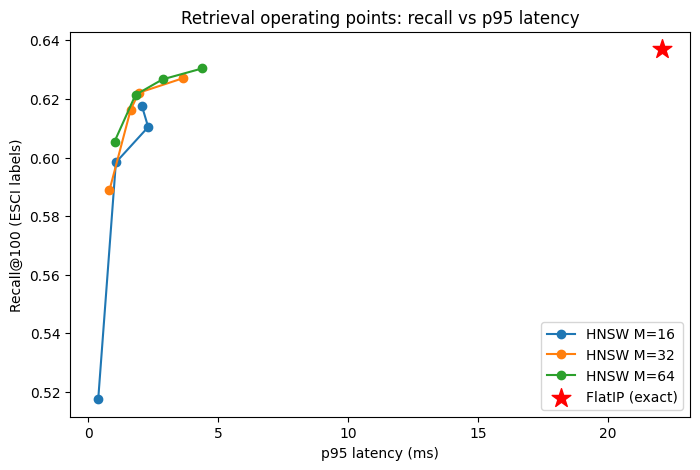

In [5]:
import matplotlib.pyplot as plt

flat_row = {
    "M": None, "efSearch": None,
    "build_time_s": flat_build_time, "index_mb": faiss.serialize_index(index_flat).nbytes / 1e6,
    "recall_vs_flat_100": 1.0,
    "recall_100_esci": float(flat_metrics["recall_100"].mean()),
    "ndcg_10": float(flat_metrics["ndcg_10"].mean()),
    "mrr_10": float(flat_metrics["mrr_10"].mean()),
    "latency_ms_median": float(np.median(latencies_flat)),
    "latency_ms_p95": float(np.percentile(latencies_flat, 95)),
    "latency_ms_p99": float(np.percentile(latencies_flat, 99)),
    "index_type": "FlatIP",
}
hnsw_results_df["index_type"] = "HNSW"

benchmark_df = pd.concat([pd.DataFrame([flat_row]), hnsw_results_df], ignore_index=True)
benchmark_df.to_csv("../reports/retrieval_benchmark.csv", index=False)
print("saved reports/retrieval_benchmark.csv")
benchmark_df

fig, ax = plt.subplots(figsize=(8, 5))
for M in M_GRID:
    sub = hnsw_results_df[hnsw_results_df["M"] == M]
    ax.plot(sub["latency_ms_p95"], sub["recall_100_esci"], marker="o", label=f"HNSW M={M}")
ax.scatter([flat_row["latency_ms_p95"]], [flat_row["recall_100_esci"]], color="red", marker="*", s=200, label="FlatIP (exact)")
ax.set_xlabel("p95 latency (ms)")
ax.set_ylabel("Recall@100 (ESCI labels)")
ax.set_title("Retrieval operating points: recall vs p95 latency")
ax.legend()
plt.show()


In [6]:
fig.savefig("../reports/figures/retrieval_pareto.png", dpi=150, bbox_inches="tight")
print("saved reports/figures/retrieval_pareto.png")


saved reports/figures/retrieval_pareto.png


In [7]:
faiss.write_index(index_hnsw, "../artifacts/indexes/hnsw_m64_ef256.faiss")
print("saved index, efSearch currently =", index_hnsw.hnsw.efSearch)

import json
chosen_row = hnsw_results_df[(hnsw_results_df["M"] == 64) & (hnsw_results_df["efSearch"] == 256)].iloc[0]
chosen_config = {
    "index_type": "HNSW",
    "M": 64,
    "efSearch": 256,
    "metric": "inner_product",
    "catalogue_size": int(len(product_ids)),
    "recall_100_esci": float(chosen_row["recall_100_esci"]),
    "recall_vs_flat_100": float(chosen_row["recall_vs_flat_100"]),
    "ndcg_10": float(chosen_row["ndcg_10"]),
    "mrr_10": float(chosen_row["mrr_10"]),
    "latency_ms_median": float(chosen_row["latency_ms_median"]),
    "latency_ms_p95": float(chosen_row["latency_ms_p95"]),
    "index_mb": float(chosen_row["index_mb"]),
    "decision_rule": (
        "Highest ESCI Recall@100 among configs with p95<50ms and index<1GB. "
        "Every config (incl. FlatIP) cleared both bounds trivially at this 164k-vector scale, "
        "so the budget constraint didn't discriminate; HNSW M=64/ef=256 chosen over FlatIP to "
        "demonstrate the ANN recall/latency/memory trade-off methodology relevant at production "
        "scale, not because FlatIP was too slow here (FlatIP p95=22ms is also fine). IVF-PQ "
        "skipped: its value is memory compression, and there's no memory pressure to solve at ~590MB."
    ),
}
with open("../artifacts/indexes/chosen_index_config.json", "w") as f:
    json.dump(chosen_config, f, indent=2)
print(json.dumps(chosen_config, indent=2))


saved index, efSearch currently = 256
{
  "index_type": "HNSW",
  "M": 64,
  "efSearch": 256,
  "metric": "inner_product",
  "catalogue_size": 164006,
  "recall_100_esci": 0.6303867644772291,
  "recall_vs_flat_100": 0.9836050926960018,
  "ndcg_10": 0.4186846159547053,
  "mrr_10": 0.6693436647982102,
  "latency_ms_median": 1.4301538467407227,
  "latency_ms_p95": 4.375267028808594,
  "index_mb": 590.427038,
  "decision_rule": "Highest ESCI Recall@100 among configs with p95<50ms and index<1GB. Every config (incl. FlatIP) cleared both bounds trivially at this 164k-vector scale, so the budget constraint didn't discriminate; HNSW M=64/ef=256 chosen over FlatIP to demonstrate the ANN recall/latency/memory trade-off methodology relevant at production scale, not because FlatIP was too slow here (FlatIP p95=22ms is also fine). IVF-PQ skipped: its value is memory compression, and there's no memory pressure to solve at ~590MB."
}


In [3]:
faiss.write_index(index_hnsw, "../artifacts/indexes/hnsw_m64_ef256.faiss")

import os
index_size_mb = os.path.getsize("../artifacts/indexes/hnsw_m64_ef256.faiss") / 1e6
print(f"overwrote hnsw_m64_ef256.faiss, {index_size_mb:.1f}MB")


overwrote hnsw_m64_ef256.faiss, 1735.6MB


In [4]:
import sys
sys.path.append("../src")
from retrieval import compute_metrics

judgments = pd.read_parquet("../data/processed/judgments.parquet")
val_ids = set(pd.read_csv("../data/processed/splits/validation_query_ids.csv")["query_id"])

query_embeddings = np.load("../artifacts/indexes/query_embeddings.npy")
query_ids_emb = pd.read_csv("../artifacts/indexes/query_embedding_ids.csv")["query_id"].to_numpy()
val_mask = np.isin(query_ids_emb, list(val_ids))
val_query_ids = query_ids_emb[val_mask]
val_query_embeddings = query_embeddings[val_mask]
split_judgments = judgments[judgments["query_id"].isin(val_query_ids)]

def chunked_search(index, queries, k, chunk_size=500):
    all_scores, all_idx = [], []
    for start in range(0, len(queries), chunk_size):
        chunk = queries[start:start+chunk_size]
        scores, idx = index.search(chunk, k)
        all_scores.append(scores)
        all_idx.append(idx)
    return np.vstack(all_scores), np.vstack(all_idx)

K = 100

t0 = time.time()
flat_scores, flat_idx = chunked_search(index_flat, val_query_embeddings, K)
print(f"FlatIP search: {time.time()-t0:.1f}s")
flat_predicted_ids = product_ids[flat_idx]
flat_metrics = compute_metrics(list(val_query_ids), flat_predicted_ids, split_judgments)
print("FlatIP:", flat_metrics[["recall_100", "ndcg_10", "mrr_10"]].mean().to_dict())

t0 = time.time()
hnsw_scores, hnsw_idx = index_hnsw.search(val_query_embeddings, K)
print(f"HNSW search: {time.time()-t0:.1f}s")
hnsw_predicted_ids = product_ids[hnsw_idx]
hnsw_metrics = compute_metrics(list(val_query_ids), hnsw_predicted_ids, split_judgments)
print("HNSW M=64/ef=256:", hnsw_metrics[["recall_100", "ndcg_10", "mrr_10"]].mean().to_dict())


FlatIP search: 19.5s
FlatIP: {'recall_100': 0.5093972248258759, 'ndcg_10': 0.3236226354863515, 'mrr_10': 0.5607789903244449}
HNSW search: 4.2s
HNSW M=64/ef=256: {'recall_100': 0.49977942316635554, 'ndcg_10': 0.31874567839533374, 'mrr_10': 0.5524907729453183}
